# 03 · Inference & Evidence Pack

**Module 4 · Unit 3 · Sessions 3–4**

Runs the trained model and produces everything a reviewer needs to judge it without
running anything themselves:

| Output | Folder |
|---|---|
| 5 ground-truth annotation examples | `results/evidence/annotations/` |
| 10 validation predictions | `results/evidence/validation/` |
| 5 predictions on **unseen** images | `results/evidence/new_images/` |
| Worst FP / FN / class-confusion / localization-drift crops | `results/evidence/errors/` |
| Machine-readable error tally | `results/metrics/error_analysis.json` |

**Runtime:** ~3 minutes. Loads weights — no training, so CPU is fine.


In [1]:
# ── CELL 1 ── Environment bootstrap. Run this first, every time.
# Works in Colab (clones the repo) and locally (uses the repo you are in).
import os, subprocess, sys, pathlib

REPO_URL = "https://github.com/OmarEAbdelaal/ZIGURAT-AI-AECO-Masters_Group-2.git"
SUBDIR   = "m4u3-facade-ve-vision"   # set to "" if the project is at the repo root

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    root = pathlib.Path('/content') / pathlib.Path(REPO_URL).stem
    if not root.exists():
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(root)], check=True)
    PROJECT = root / SUBDIR if SUBDIR else root
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                    str(PROJECT / 'requirements.txt')], check=True)
else:
    here = pathlib.Path.cwd()
    PROJECT = next((p for p in [here, *here.parents] if (p / 'src' / 'config.py').exists()), here)

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / 'src'))
print('project root :', PROJECT)

import config as C
print()
print(C.summary())


project root : /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision



dataset source   : synthetic
roboflow project : (not configured)
classes (5)     : window, curtain_wall, door, balcony, louvre_screen
model            : yolov8n.pt
epochs/batch/imgsz: 30 / 16 / 640
seed             : 42
conf / iou       : 0.35 / 0.5
ultralytics      : 8.4.157
torch            : 2.14.0+cu130
device           : CPU only
python           : 3.11.15 on Linux-6.18.44-fc-v37-x86_64-with-glibc2.39


## 1 · Load the weights

Prefers a local `best.pt` from notebook 02; otherwise downloads the published
release asset named in `WEIGHTS_URL`. A reader who only wants to see the model work
never has to train.


In [2]:
import urllib.request
from pathlib import Path

weights = C.RESULTS_DIR / 'weights' / 'best.pt'
if not weights.exists():
    if not C.WEIGHTS_URL:
        raise SystemExit('No local weights and WEIGHTS_URL is empty. '
                         'Run notebook 02, or publish best.pt as a GitHub Release '
                         'and set WEIGHTS_URL in src/config.py.')
    weights.parent.mkdir(parents=True, exist_ok=True)
    print('downloading weights …')
    urllib.request.urlretrieve(C.WEIGHTS_URL, weights)

print('weights:', weights, f'({weights.stat().st_size/1e6:.1f} MB)')


weights: /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/weights/best.pt (6.2 MB)


## 2 · Build the full evidence pack


In [3]:
from dataset import resolve_dataset
from evidence import build_all

data_yaml = resolve_dataset()
build_all(weights, data_yaml, n_val=10, n_new=5)


synthetic dataset already present -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/data/dataset/synthetic

  NOTE: this is the VERIFICATION dataset. It proves the pipeline runs.
        It is not evidence of real-world façade detection performance.

5 annotation examples -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/evidence/annotations


10 val predictions -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/evidence/validation


5 new predictions -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/evidence/new_images


{
  "tally": {
    "true_positive": 459,
    "false_positive": 9,
    "false_negative": 23,
    "localization_error": 6,
    "class_confusion": 3
  },
  "total_errors": 41
}
error crops -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/evidence/errors


## 3 · Validation predictions

The model on data it was scored against. Necessary, but not the honest test.


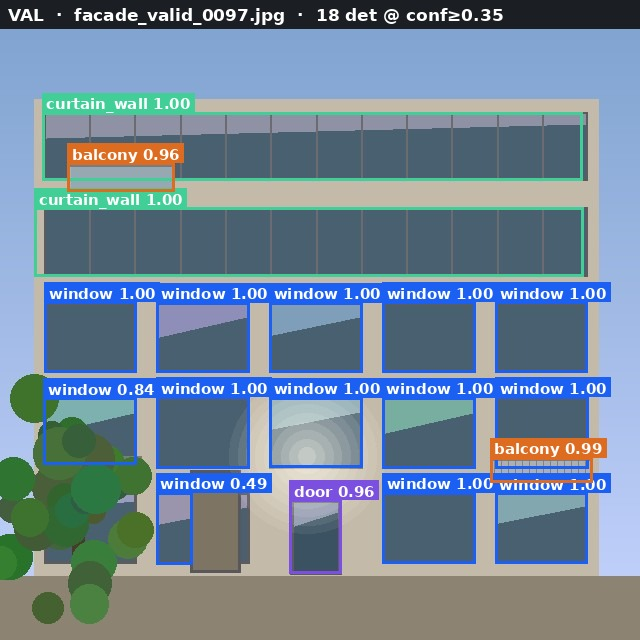

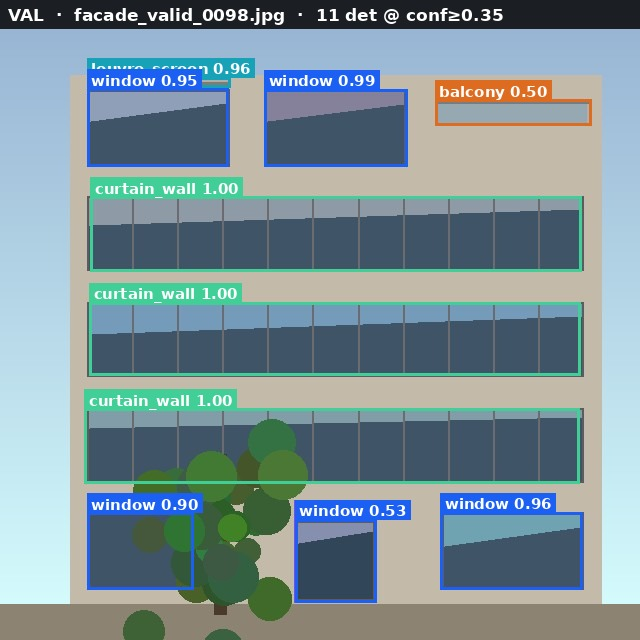

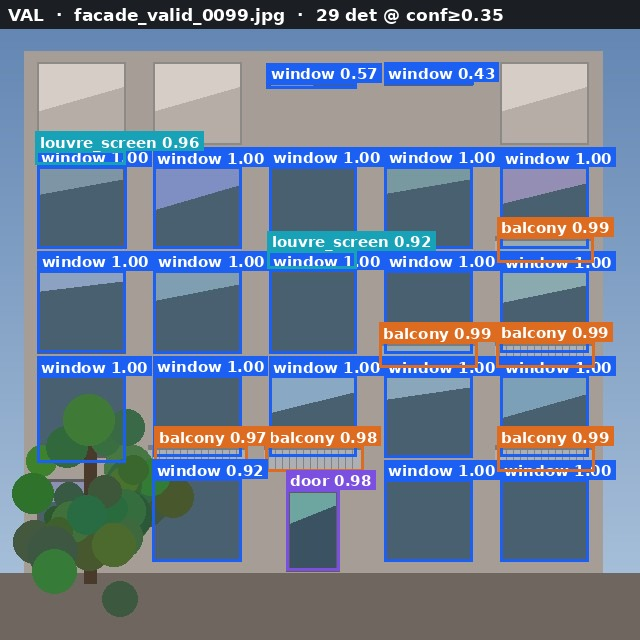

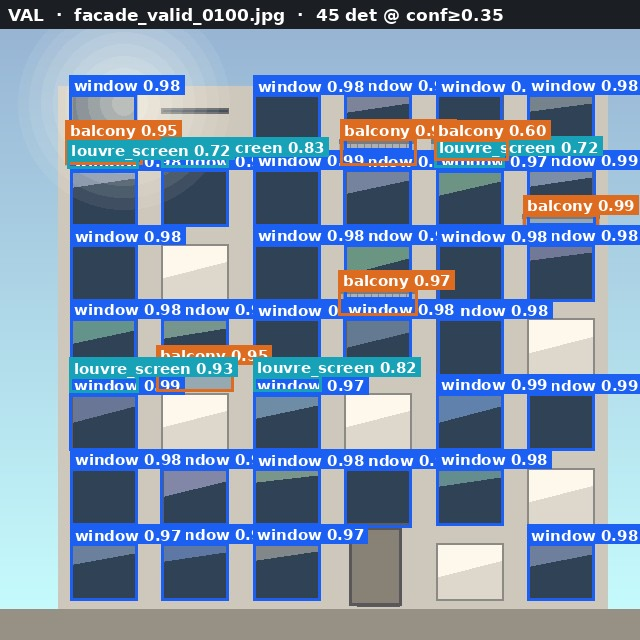

In [4]:
from IPython.display import Image as IPImage, display

for f in sorted((C.EVIDENCE_DIR / 'validation').glob('*.jpg'))[:4]:
    display(IPImage(filename=str(f), width=620))


## 4 · Unseen images — the honest test

> *"Never show a client a training image. They will think you cheated."* — Session 3

These images were in neither the training nor the validation split. This is the
result that means something.


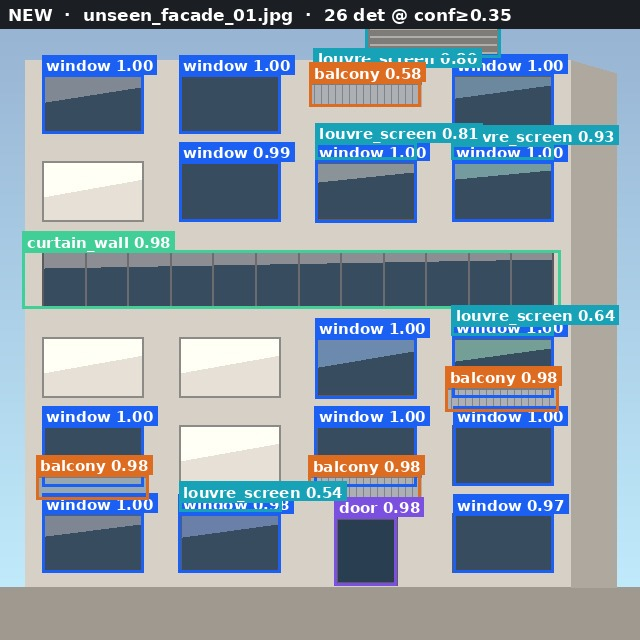

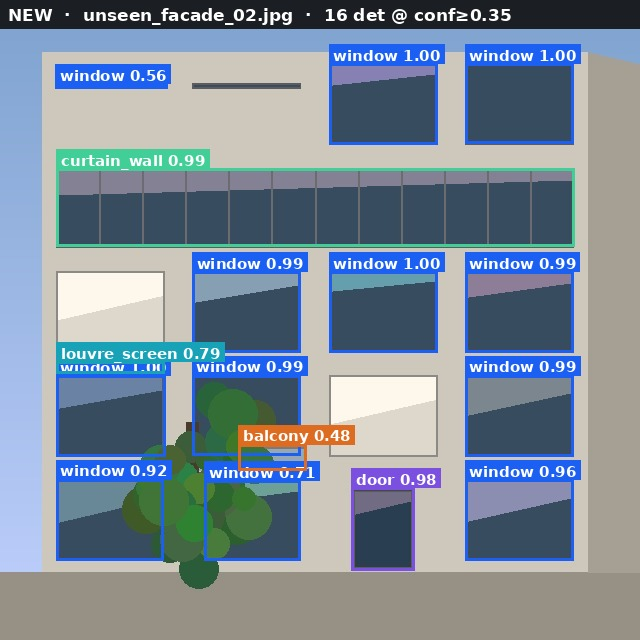

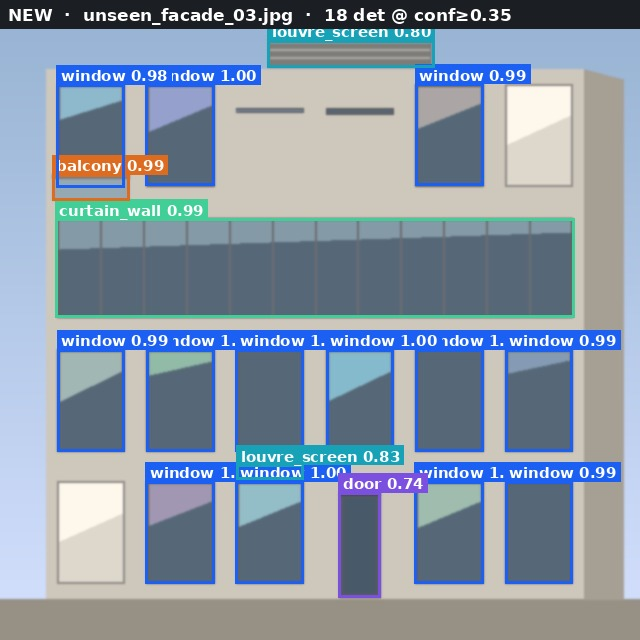

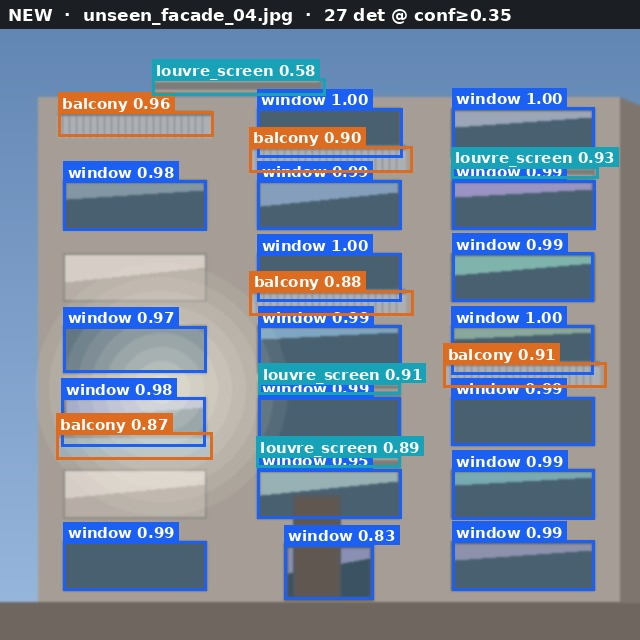

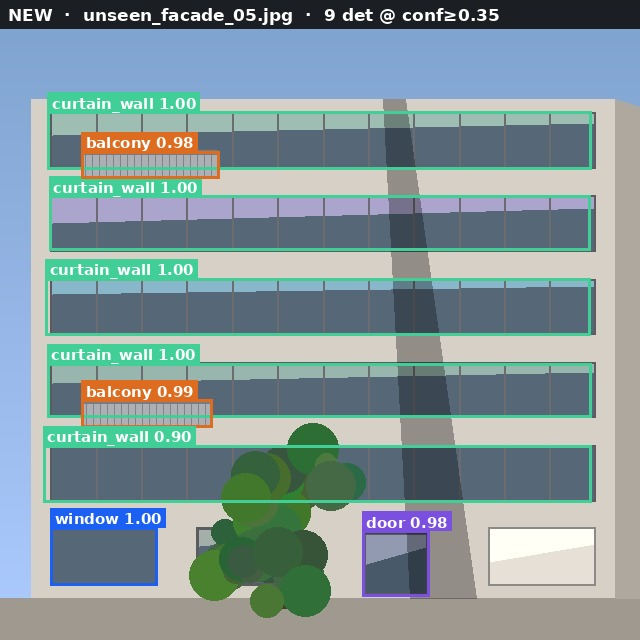

In [5]:
for f in sorted((C.EVIDENCE_DIR / 'new_images').glob('*.jpg'))[:5]:
    display(IPImage(filename=str(f), width=620))


## 5 · The Value Engineering read-out

The point of the detector. Boxes are not a deliverable — a Window-to-Wall Ratio and
an envelope cost index are, because those are what the FMP's VE engine consumes.

> **Basis:** uncalibrated pixel areas from a single image. A *relative* screening
> signal for comparing options, **never** a quantity take-off. Without a known scale
> these are not square metres and cannot become square metres.


In [6]:
import json

man_path = C.EVIDENCE_DIR / 'new_images' / 'manifest.json'
if not man_path.exists():
    man_path = C.EVIDENCE_DIR / 'validation' / 'manifest.json'
manifest = json.loads(man_path.read_text())

hdr = f"{'image':<34}{'glazed %':>10}{'cost idx':>11}   counts"
print(hdr); print('-' * (len(hdr) + 22))
for m in manifest:
    ve = m['ve']
    counts = ', '.join(f"{k}:{v}" for k, v in sorted(ve['counts'].items())) or '—'
    print(f"{m['source'][:33]:<34}"
          f"{ve['glazed_fraction_of_frame']*100:>9.1f}%"
          f"{ve['envelope_cost_index']:>11.1f}   {counts}")
print()
print('basis:', manifest[0]['ve']['basis'])


image                               glazed %   cost idx   counts
--------------------------------------------------------------------------------------
unseen_facade_01.jpg                   28.4%      195.3   balcony:4, curtain_wall:1, door:1, louvre_screen:6, window:14
unseen_facade_02.jpg                   33.1%      208.7   balcony:1, curtain_wall:1, door:1, louvre_screen:1, window:12
unseen_facade_03.jpg                   34.6%      226.2   balcony:1, curtain_wall:1, door:1, louvre_screen:2, window:13
unseen_facade_04.jpg                   30.2%      184.4   balcony:5, louvre_screen:4, window:18
unseen_facade_05.jpg                   39.1%      315.1   balcony:2, curtain_wall:5, door:1, window:1

basis: uncalibrated pixel areas — relative screening signal, not a take-off


## 6 · Error taxonomy

Session 3's four error types, counted automatically over the whole validation split
rather than eyeballed:

| Type | Meaning | AECO cost here |
|---|---|---|
| **False Positive** | detected something that is not there | phantom glazed area → inflated WWR and cost |
| **False Negative** | missed something that is | understated envelope — *silent*, so more dangerous |
| **Class Confusion** | right object, wrong name | wrong unit rate applied |
| **Localization Error** | right object, sloppy box | wrong quantity — invisible to `mAP50` |

Separating localization drift out is deliberate: at IoU 0.50–0.75 the box is counted
as correct by the headline detection metric while being materially wrong as a quantity.


In [7]:
from IPython.display import Markdown

ea = json.loads((C.METRICS_DIR / 'error_analysis.json').read_text())
t = ea['tally']
tot = ea['total_errors'] or 1

print(f"images evaluated : {ea['images_evaluated']}")
print(f"conf threshold   : {ea['conf_threshold']}\n")
print(f"{'type':<22}{'count':>7}{'% of errors':>13}")
print('-' * 42)
for k in ('true_positive','false_positive','false_negative',
          'class_confusion','localization_error'):
    v = t.get(k, 0)
    pct = '' if k == 'true_positive' else f'{v/tot*100:>12.1f}%'
    print(f'{k:<22}{v:>7}{pct}')

print('\nfalse negatives by class :', ea['false_negatives_by_class'])
print('false positives by class :', ea['false_positives_by_class'])


images evaluated : 24
conf threshold   : 0.35

type                    count  % of errors
------------------------------------------
true_positive             459
false_positive              9        22.0%
false_negative             23        56.1%
class_confusion             3         7.3%
localization_error          6        14.6%

false negatives by class : {'balcony': 2, 'window': 16, 'door': 4, 'louvre_screen': 1}
false positives by class : {'window': 7, 'door': 2}


### The worst offenders

False positives ranked by **confidence** (a confident hallucination is worse than a
hesitant one); false negatives ranked by **size** (a missed curtain wall costs more
than a missed clerestory strip).

Green box = ground truth · Red = prediction · Orange = missed instance



FALSE POSITIVES


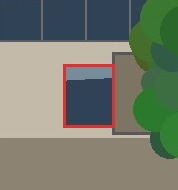

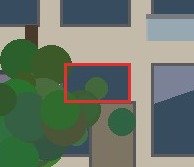

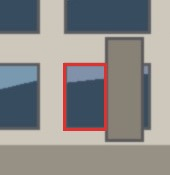


FALSE NEGATIVES


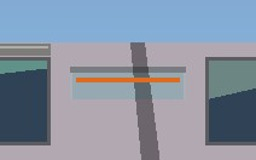

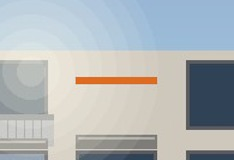

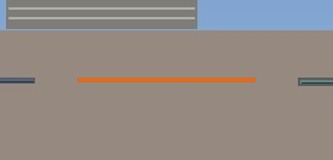


CLASS CONFUSION


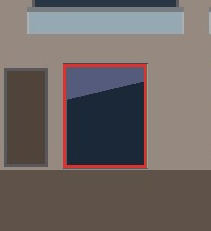

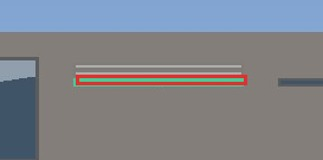

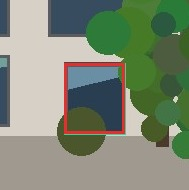


LOCALIZATION DRIFT


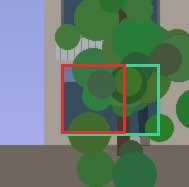

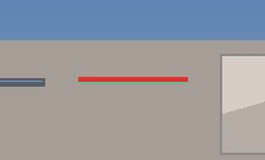

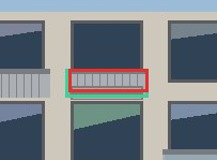

In [8]:
for tag, label in [('fp','FALSE POSITIVES'), ('fn','FALSE NEGATIVES'),
                   ('confusion','CLASS CONFUSION'), ('drift','LOCALIZATION DRIFT')]:
    files = sorted((C.EVIDENCE_DIR / 'errors').glob(f'{tag}_*.jpg'))[:3]
    if not files:
        continue
    print(f'\n{"="*62}\n{label}\n{"="*62}')
    for f in files:
        display(IPImage(filename=str(f), width=380))


## 7 · Write up what you just saw

The numbers above are the evidence. The interpretation is the deliverable, and it
goes in [`docs/error_analysis.md`](../docs/error_analysis.md): three false positives,
three false negatives, a hypothesis for each, and three concrete dataset improvements
that follow from them.

> *"I will give more points for a well-explained failure than a fake success."*
> — Session 4
